# Section 3 — Advanced Anomaly Detection

Anomaly detection in network traffic is essential for identifying potential security threats. This section analyses the data to detect various types of anomalous behaviour.

**Three sub-sections:**
- **3a. Statistical Analysis** — Z-score thresholds on packet sizes, flow counts, byte volumes, protocol distribution, hourly vs daily comparison
- **3b. Behavioural Analysis** — spike after inactivity, coordinated multi-source attacks, persistent DDoS targets
- **3c. Suspicious Patterns** — long-duration connections, multi-protocol behaviour

**Thresholds used:**
- `mean + 3σ` for flow count and byte volume anomalies (flags top ~0.3%)
- `mean + 2σ` for DDoS detection (catch early signs, acceptable false positive rate)
- IQR-based for packet size thresholds (robust to skewed data)
- 10-minute window for multi-protocol detection

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_files = sorted(glob.glob('b/*.csv'))
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

df['startDateTime'] = pd.to_datetime(df['startDateTime'], errors='coerce')
df['stopDateTime'] = pd.to_datetime(df['stopDateTime'], errors='coerce')
df['totalBytes'] = df['totalSourceBytes'] + df['totalDestinationBytes']
df['hour'] = df['startDateTime'].dt.floor('h')
df['day'] = df['startDateTime'].dt.floor('D')

print(f"Loaded {len(df):,} flows")

Loaded 2,071,657 flows


## (a) Statistical Traffic Analysis

Defining thresholds for anomalies in packet sizes, flow counts, and protocol distributions.

In [2]:
# packet size threshold using IQR (robust to skewed data)
q1 = df['totalBytes'].quantile(0.25)
q3 = df['totalBytes'].quantile(0.75)
iqr = q3 - q1
pkt_threshold = q3 + 1.5 * iqr

# flow count thresholds
flows_per_hour = df.groupby('hour').size()
flows_per_day = df.groupby('day').size()
hourly_threshold = flows_per_hour.mean() + 2 * flows_per_hour.std()
daily_threshold = flows_per_day.mean() + flows_per_day.std()

print(f"Packet size threshold (IQR): {pkt_threshold:,.0f} bytes")
print(f"Hourly flow threshold (mean+2std): {hourly_threshold:,.0f} flows/hr")
print(f"Daily flow threshold (mean+std): {daily_threshold:,.0f} flows/day")

# protocol distribution baseline
proto_pct = df['protocolName'].value_counts(normalize=True) * 100
print("\nProtocol distribution:")
for proto, pct in proto_pct.items():
    print(f"  {proto}: {pct:.2f}%")

Packet size threshold (IQR): 19,788 bytes
Hourly flow threshold (mean+2std): 40,417 flows/hr
Daily flow threshold (mean+std): 507,149 flows/day

Protocol distribution:
  tcp_ip: 79.36%
  udp_ip: 20.24%
  icmp_ip: 0.40%
  igmp: 0.00%
  ip: 0.00%
  ipv6icmp: 0.00%


### Comparing hourly vs daily traffic patterns

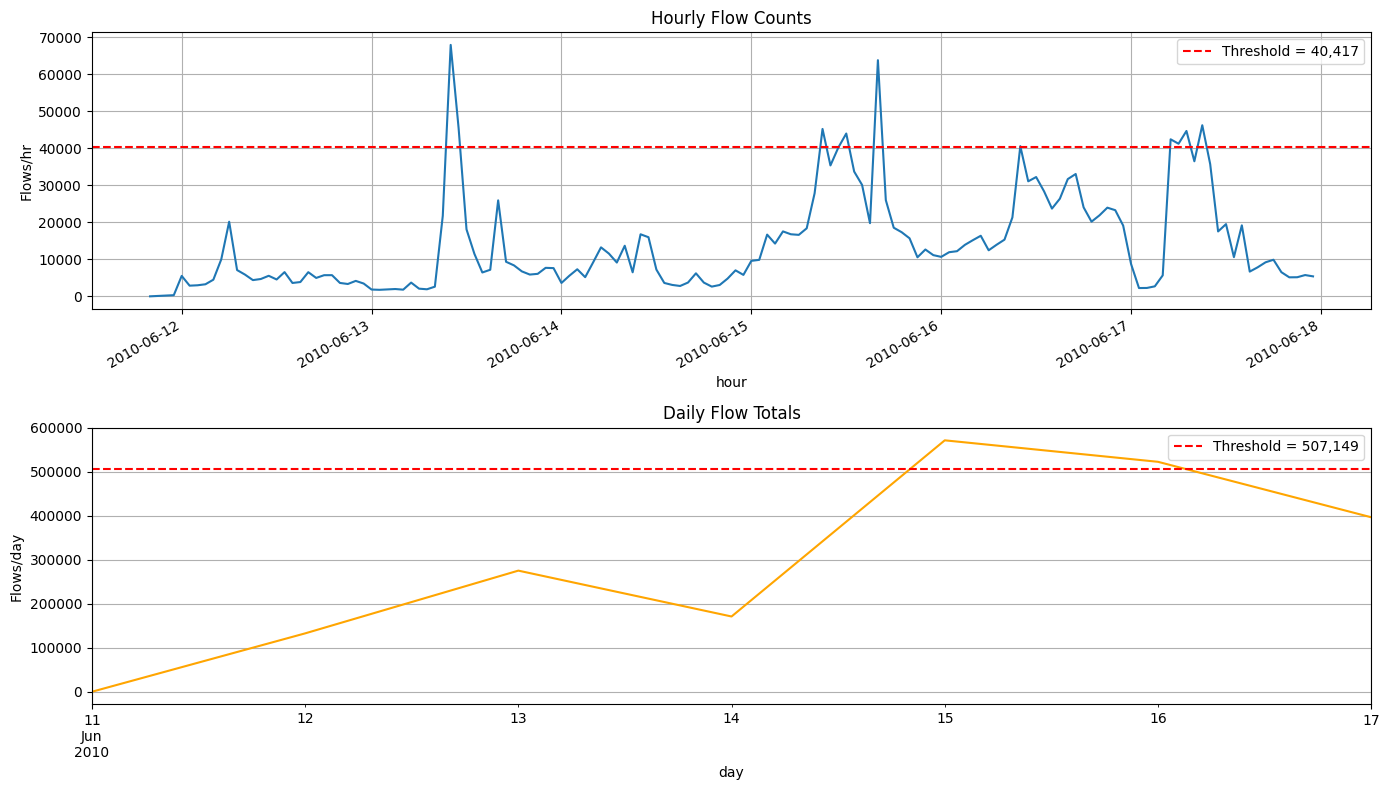

Anomalous: 2010-06-15 - 571,699 flows, max hourly 63,821 - Short-term burst
Anomalous: 2010-06-16 - 522,896 flows, max hourly 40,588 - Short-term burst
Hidden anomaly: 2010-06-13 - normal daily total but hourly spike of 67,952
Hidden anomaly: 2010-06-17 - normal daily total but hourly spike of 46,246


In [3]:
# plotting hourly and daily
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

flows_per_hour.plot(ax=ax1)
ax1.axhline(hourly_threshold, color='red', linestyle='--', label=f'Threshold = {hourly_threshold:,.0f}')
ax1.set_title('Hourly Flow Counts')
ax1.set_ylabel('Flows/hr')
ax1.legend()
ax1.grid(True)

flows_per_day.plot(ax=ax2, color='orange')
ax2.axhline(daily_threshold, color='red', linestyle='--', label=f'Threshold = {daily_threshold:,.0f}')
ax2.set_title('Daily Flow Totals')
ax2.set_ylabel('Flows/day')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# checking which days are anomalous
anomalous_days = flows_per_day[flows_per_day > daily_threshold]
for day in anomalous_days.index:
    hourly = flows_per_hour[flows_per_hour.index.date == day.date()]
    max_h = hourly.max() if not hourly.empty else 0
    atype = 'Short-term burst' if max_h > hourly_threshold else 'Sustained elevated traffic'
    print(f"Anomalous: {day.date()} - {anomalous_days[day]:,} flows, max hourly {max_h:,} - {atype}")

# also check for hidden anomalies (normal daily but with hourly spike)
normal_days = flows_per_day[flows_per_day <= daily_threshold]
for day in normal_days.index:
    hourly = flows_per_hour[flows_per_hour.index.date == day.date()]
    if not hourly.empty and hourly.max() > hourly_threshold:
        print(f"Hidden anomaly: {day.date()} - normal daily total but hourly spike of {hourly.max():,}")

### Flagging IPs with abnormal traffic volume

In [4]:
# Flag IPs by FLOW COUNT
ip_flow_counts = df.groupby('source').size()
fc_mean = ip_flow_counts.mean()
fc_std = ip_flow_counts.std()
fc_threshold = fc_mean + 3 * fc_std

high_flow_ips = ip_flow_counts[ip_flow_counts > fc_threshold].sort_values(ascending=False)

print(f"Flow count anomalies (threshold = mean + 3*std = {fc_threshold:,.0f} flows):")
print(f"  Mean per IP: {fc_mean:.1f} flows")
print(f"  IPs flagged: {len(high_flow_ips)}")
print()
print(f"  {'IP':<20} {'Flows':>10} {'Z-score':>8}")
print(f"  {'-'*20} {'-'*10} {'-'*8}")
for ip, cnt in high_flow_ips.head(10).items():
    z = (cnt - fc_mean) / fc_std
    print(f"  {ip:<20} {cnt:>10,} {z:>7.1f}σ")

# Flag IPs by BYTE VOLUME
source_traffic = df.groupby('source')['totalSourceBytes'].sum()
bt_mean = source_traffic.mean()
bt_std = source_traffic.std()
byte_threshold = bt_mean + 3 * bt_std

high_byte_ips = source_traffic[source_traffic > byte_threshold].sort_values(ascending=False)

print(f"\nByte volume anomalies (threshold = mean + 3*std = {byte_threshold/1e6:.1f} MB):")
print(f"  IPs flagged: {len(high_byte_ips)}")
print()
print(f"  {'IP':<20} {'Bytes Sent':>15} {'Z-score':>8}")
print(f"  {'-'*20} {'-'*15} {'-'*8}")
for ip, b in high_byte_ips.head(10).items():
    z = (b - bt_mean) / bt_std
    print(f"  {ip:<20} {b/1e6:>12.1f} MB {z:>7.1f}σ")

# Also IQR-based low traffic
q1s = source_traffic.quantile(0.25)
q3s = source_traffic.quantile(0.75)
iqrs = q3s - q1s
low_traffic = source_traffic[source_traffic < q1s - 1.5 * iqrs]
print(f"\nLow-traffic outlier IPs (IQR): {len(low_traffic)}")

Flow count anomalies (threshold = mean + 3*std = 30,984 flows):
  Mean per IP: 836.0 flows
  IPs flagged: 21

  IP                        Flows  Z-score
  -------------------- ---------- --------
  192.168.5.122           268,267    26.6σ
  192.168.2.107           208,379    20.7σ
  192.168.4.118           135,374    13.4σ
  192.168.1.101           116,292    11.5σ
  192.168.4.121           105,454    10.4σ
  192.168.1.105           101,359    10.0σ
  192.168.2.109            99,183     9.8σ
  192.168.3.116            97,241     9.6σ
  192.168.2.110            90,658     8.9σ
  192.168.3.115            88,915     8.8σ

Byte volume anomalies (threshold = mean + 3*std = 118.8 MB):
  IPs flagged: 14

  IP                        Bytes Sent  Z-score
  -------------------- --------------- --------
  192.168.2.107              1766.7 MB    45.3σ
  192.168.4.121               348.2 MB     8.9σ
  192.168.2.109               279.6 MB     7.1σ
  192.168.1.105               234.0 MB     6.0σ
  192

## (b) Behavioural Analysis

### Detecting sudden spikes after inactivity

In [5]:
# for each source IP, check if it was idle for an hour then suddenly sent >50KB
traffic_by_hour = df.groupby(['source', 'hour'])['totalSourceBytes'].sum().unstack(fill_value=0)
traffic_diffs = traffic_by_hour.diff(axis=1).fillna(0)

spike_threshold = 50000  # 50 KB
behavioral_spikes = []

for ip in traffic_by_hour.index:
    series = traffic_by_hour.loc[ip]
    diffs = traffic_diffs.loc[ip]
    idle = (series == 0)
    idle_prev = idle.shift(1).fillna(True)
    if any(idle_prev & (diffs > spike_threshold)):
        behavioral_spikes.append(ip)

print(f"IPs with sudden spikes after inactivity: {len(behavioral_spikes)}")
for ip in behavioral_spikes:
    max_spike = traffic_diffs.loc[ip].max()
    print(f"  {ip}: max spike {max_spike/1000:.1f} KB")

IPs with sudden spikes after inactivity: 16
  131.202.240.209: max spike 59.8 KB
  131.202.243.90: max spike 5173.1 KB
  142.167.88.44: max spike 5474.3 KB
  187.60.74.67: max spike 4577.3 KB
  192.168.3.115: max spike 3951.4 KB
  192.168.3.117: max spike 5273.3 KB
  192.168.4.121: max spike 126249.8 KB
  192.168.5.124: max spike 82.7 KB
  65.55.34.12: max spike 52.1 KB
  67.195.23.154: max spike 74.3 KB
  67.195.8.62: max spike 184.6 KB
  67.195.9.84: max spike 74.2 KB
  67.23.167.37: max spike 52.3 KB
  80.66.211.179: max spike 452.0 KB
  98.137.26.79: max spike 74.2 KB
  98.139.91.71: max spike 74.5 KB


### Network-wide correlation

Detecting multiple IPs contacting the same target within a short time interval. Using 15-minute windows to capture short coordinated bursts.

In [6]:
df['window_15m'] = df['startDateTime'].dt.floor('15min')

# count unique sources per (destination, 15-min window)
corr_counts = df.groupby(['destination', 'window_15m'])['source'].nunique().reset_index(name='unique_sources')

q1c = corr_counts['unique_sources'].quantile(0.25)
q3c = corr_counts['unique_sources'].quantile(0.75)
iqrc = q3c - q1c
if iqrc == 0:
    corr_threshold = corr_counts['unique_sources'].quantile(0.995)
else:
    corr_threshold = q3c + 1.5 * iqrc

coordinated = corr_counts[corr_counts['unique_sources'] > corr_threshold].sort_values('unique_sources', ascending=False)

print(f"Correlation threshold: {corr_threshold:.0f} unique sources per 15-min window")
print(f"Flagged (destination, window) pairs: {len(coordinated)}")
print()
print("Top 10 most targeted destinations:")
top_targets = coordinated.groupby('destination')['unique_sources'].max().sort_values(ascending=False).head(10)
for dst, cnt in top_targets.items():
    print(f"  {dst}: up to {cnt} sources in one window")

Correlation threshold: 8 unique sources per 15-min window
Flagged (destination, window) pairs: 772

Top 10 most targeted destinations:
  192.168.2.107: up to 229 sources in one window
  192.168.5.122: up to 34 sources in one window
  142.166.14.72: up to 13 sources in one window
  142.166.14.80: up to 13 sources in one window
  142.166.14.78: up to 12 sources in one window
  142.166.14.85: up to 12 sources in one window
  142.166.14.69: up to 11 sources in one window
  142.166.14.71: up to 11 sources in one window
  142.166.14.79: up to 11 sources in one window
  142.166.14.70: up to 10 sources in one window


### Persistent DDoS targets

Destination IPs that receive traffic from an unusually high number of distinct sources across the entire dataset — sustained attack targets.

In [7]:
# all-time distinct sources per destination
dst_src_counts = df.groupby('destination')['source'].nunique().sort_values(ascending=False)
ds_mean = dst_src_counts.mean()
ds_std = dst_src_counts.std()
ds_threshold = ds_mean + 2 * ds_std

persistent_targets = dst_src_counts[dst_src_counts > ds_threshold]

print(f"Persistent DDoS targets (threshold = mean + 2*std = {ds_threshold:.0f} distinct sources):")
print(f"  Mean distinct sources per destination: {ds_mean:.2f}")
print(f"  Flagged destinations: {len(persistent_targets)}")
print()
print(f"  {'Destination IP':<22} {'Distinct Sources':>18} {'Z-score':>8}")
print(f"  {'-'*22} {'-'*18} {'-'*8}")
for dst, cnt in persistent_targets.items():
    z = (cnt - ds_mean) / ds_std
    print(f"  {dst:<22} {cnt:>18,} {z:>7.1f}σ")

Persistent DDoS targets (threshold = mean + 2*std = 28 distinct sources):
  Mean distinct sources per destination: 1.74
  Flagged destinations: 2

  Destination IP           Distinct Sources  Z-score
  ---------------------- ------------------ --------
  192.168.2.107                       2,345   181.7σ
  192.168.5.122                         104     7.9σ


## (c) Suspicious Communication Patterns

### Long-duration connections

Duration threshold: 480.0 seconds
Long-duration flows: 9,975

Top 10 longest flows:
  192.168.1.101 -> 192.168.1.255: 49140s (819.0 min)
  192.168.1.101 -> 255.255.255.255: 49140s (819.0 min)
  192.168.2.109 -> 192.168.2.255: 48960s (816.0 min)
  192.168.2.109 -> 255.255.255.255: 48960s (816.0 min)
  192.168.2.112 -> 192.168.2.255: 48900s (815.0 min)
  192.168.2.112 -> 255.255.255.255: 48900s (815.0 min)
  192.168.2.112 -> 192.168.2.109: 48900s (815.0 min)
  192.168.3.117 -> 255.255.255.255: 48780s (813.0 min)
  192.168.3.114 -> 192.168.3.255: 48780s (813.0 min)
  192.168.3.114 -> 255.255.255.255: 48780s (813.0 min)


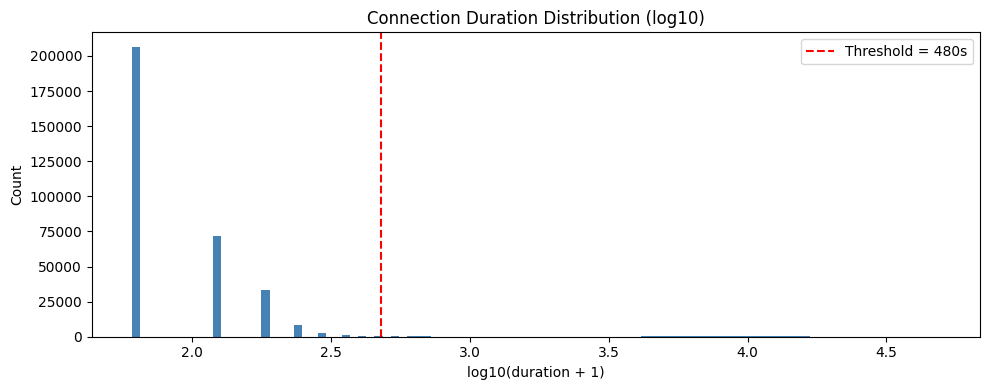

In [8]:
df['duration'] = (df['stopDateTime'] - df['startDateTime']).dt.total_seconds()

q1d = df['duration'].quantile(0.25)
q3d = df['duration'].quantile(0.75)
iqrd = q3d - q1d
if iqrd == 0:
    dur_threshold = df['duration'].quantile(0.995)
else:
    dur_threshold = q3d + 1.5 * iqrd

long_flows = df[df['duration'] > dur_threshold]

print(f"Duration threshold: {dur_threshold:.1f} seconds")
print(f"Long-duration flows: {len(long_flows):,}")
print()
print("Top 10 longest flows:")
top_long = long_flows.sort_values('duration', ascending=False)[['source', 'destination', 'duration']].head(10)
for _, row in top_long.iterrows():
    print(f"  {row['source']} -> {row['destination']}: {row['duration']:.0f}s ({row['duration']/60:.1f} min)")

# histogram
plt.figure(figsize=(10, 4))
pos_dur = df[df['duration'] > 0]['duration']
plt.hist(np.log10(pos_dur + 1), bins=100, color='steelblue', edgecolor='none')
plt.axvline(np.log10(dur_threshold + 1), color='red', linestyle='--', label=f'Threshold = {dur_threshold:.0f}s')
plt.title('Connection Duration Distribution (log10)')
plt.xlabel('log10(duration + 1)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### Multi-protocol bursts

IPs using multiple protocols within a 10-minute window. A tighter window catches more suspicious behaviour where an IP rapidly switches protocols (e.g., TCP scan followed by UDP exfiltration).

In [9]:
df['window_10m'] = df['startDateTime'].dt.floor('10min')

proto_per_window = df.groupby(['source', 'window_10m'])['protocolName'].nunique()

# flag IPs using >= 3 protocols in a single 10-min window
suspicious_proto = proto_per_window[proto_per_window >= 3]

# get details for each flagged IP
multi_proto_ips = []
for (ip, window), count in suspicious_proto.items():
    protos = df[(df['source'] == ip) & (df['window_10m'] == window)]['protocolName'].unique()
    multi_proto_ips.append((ip, count, ', '.join(sorted(protos))))

# deduplicate by IP, keep the one with most protocols
seen = {}
for ip, count, protos in multi_proto_ips:
    if ip not in seen or count > seen[ip][0]:
        seen[ip] = (count, protos)

print(f"Multi-protocol IPs (>= 3 protocols in 10-min window):")
print(f"  IPs flagged: {len(seen)}")
print()
print(f"  {'Source IP':<22} {'# Protocols':>12}  Protocols used")
print(f"  {'-'*22} {'-'*12}  {'-'*30}")
for ip, (count, protos) in sorted(seen.items(), key=lambda x: x[1][0], reverse=True):
    print(f"  {ip:<22} {count:>12}  {protos}")

Multi-protocol IPs (>= 3 protocols in 10-min window):
  IPs flagged: 9

  Source IP               # Protocols  Protocols used
  ---------------------- ------------  ------------------------------
  192.168.2.107                     4  icmp_ip, igmp, tcp_ip, udp_ip
  0.0.0.0                           3  ip, ipv6icmp, udp_ip
  192.168.1.101                     3  igmp, tcp_ip, udp_ip
  192.168.1.105                     3  icmp_ip, tcp_ip, udp_ip
  192.168.2.112                     3  icmp_ip, tcp_ip, udp_ip
  192.168.3.117                     3  igmp, tcp_ip, udp_ip
  192.168.4.120                     3  igmp, tcp_ip, udp_ip
  192.168.4.121                     3  igmp, tcp_ip, udp_ip
  192.168.5.122                     3  icmp_ip, tcp_ip, udp_ip
